In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import os
import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
from IPython.display import display

In [4]:
file_path = os.path.join("..", "data", "processed", "features_engineered.csv")

# Read CSV with index_col=0 to avoid unnamed column issues
data = pd.read_csv(file_path, index_col=0)
data

,Enrollment_ID,Study_Prog_Name,Study_Prog_Exam_Completed,Prior_Edu_Type,Prior_Edu_School_Location,Prior_Edu_Postcode,Prior_Edu_Country,Study_Prog_Group_Size,Student_Enrollment_Gap,Exit_Status
0,1546413,Arts_Therapies,1,MBO,UTRECHT,3572_LP,NL,347,164.0,leaving_unsuccessfully
1,1549026,Arts_Therapies,0,MBO,AMERSFOORT,3818_ET,NL,347,68.0,leaving_unsuccessfully
2,1543665,Arts_Therapies,1,MBO,APELDOORN,7331_VZ,NL,347,49.0,leaving_unsuccessfully
3,1556941,Arts_Therapies,0,VWO,ALKMAAR,1817_BC,NL,347,11.0,leaving_unsuccessfully
4,1536214,Arts_Therapies,1,HAVO,GOUDA,2803_ZV,NL,347,63.0,leaving_unsuccessfully
...,...,...,...,...,...,...,...,...,...,...
48386,1964301,Biology_Medical_Laboratory_Research,0,VWO,TILBURG,Others,NL,1663,51.0,leaving_unsuccessfully
48387,1966882,Biology_Medical_Laboratory_Research,0,VWO,'S-GRAVENHAGE,Others,NL,1663,51.0,leaving_unsuccessfully
48388,1972247,Biology_Medical_Laboratory_Research,1,EDUCATIE,0000_ABROAD,0000_ABROAD,outside_NL,1663,-16.0,leaving_successfully
48389,1973119,Biology_Medical_Laboratory_Research,0,HAVO,'S-HERTOGENBOSCH,5216_EG,NL,1663,99.0,leaving_unsuccessfully


In [5]:
data.columns

Index(['Enrollment_ID', 'Study_Prog_Name', 'Study_Prog_Exam_Completed',
       'Prior_Edu_Type', 'Prior_Edu_School_Location', 'Prior_Edu_Postcode',
       'Prior_Edu_Country', 'Study_Prog_Group_Size', 'Student_Enrollment_Gap',
       'Exit_Status'],
      dtype='object')

# Analyze which Study Programs have the most students in each Exit_Status category.

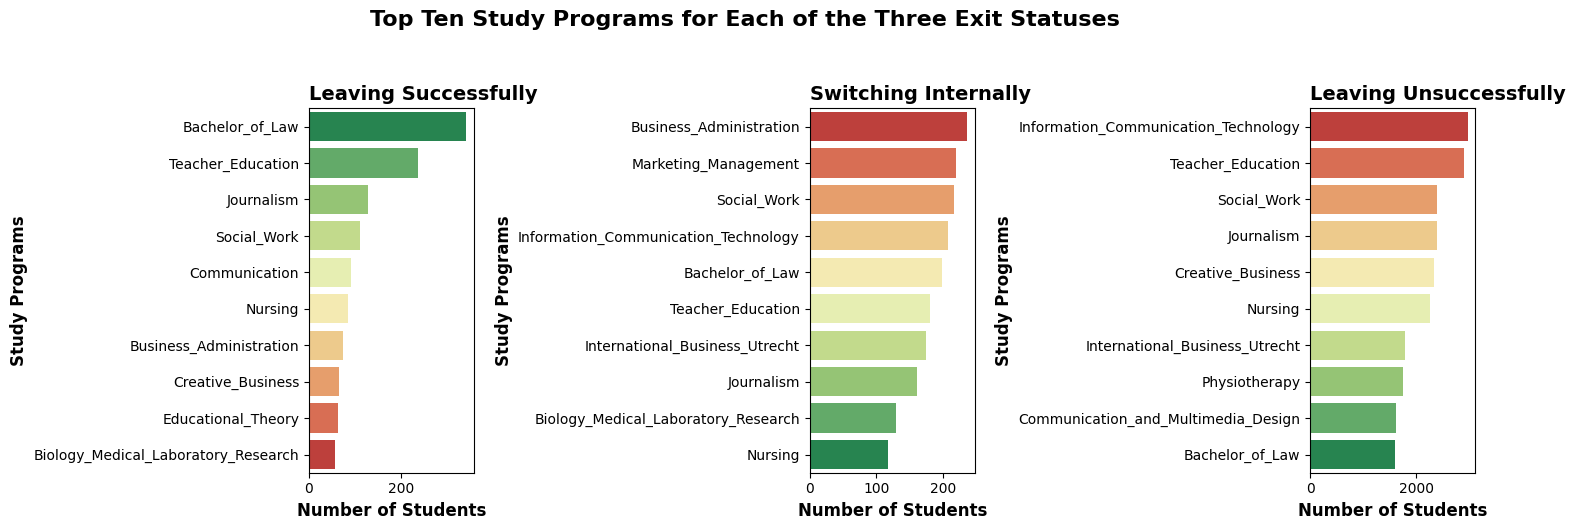

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(15, 5))

# Set the general title for the entire figure
plt.suptitle("Top Ten Study Programs for Each of the Three Exit Statuses", fontsize=16, fontweight='bold', y=1.05)

# Specify the order of the Exit_Status categories
status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']

# Loop through each Exit_Status category in the specified order
for i, status in enumerate(status_order):
    plt.subplot(1, 3, i + 1)
    top_programs = data[data['Exit_Status'] == status]['Study_Prog_Name'].value_counts().nlargest(10)
    
    # Set the color palette for each category
    if status == 'leaving_successfully':
        # Green to Red for Leaving Successfully
        palette = sns.color_palette("RdYlGn_r", len(top_programs))  # Reversed Green to Red palette
    else:
        # Red to Green for Switching Internally and Leaving Unsuccessfully
        palette = sns.color_palette("RdYlGn", len(top_programs))  # Red to Green palette

    # Create bar plot
    sns.barplot(x=top_programs.values, y=top_programs.index, palette=palette)
    
    # Title and labels for each subplot with left alignment
    plt.title(f"{status.replace('_', ' ').title()}", fontsize=14, fontweight='bold', loc='left')  # Specific title for each plot
    plt.xlabel("Number of Students", fontsize=12, fontweight='bold')
    plt.ylabel("Study Programs", fontsize=12, fontweight='bold')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


# Check if the gap between prior education and enrollment affects the exit status.

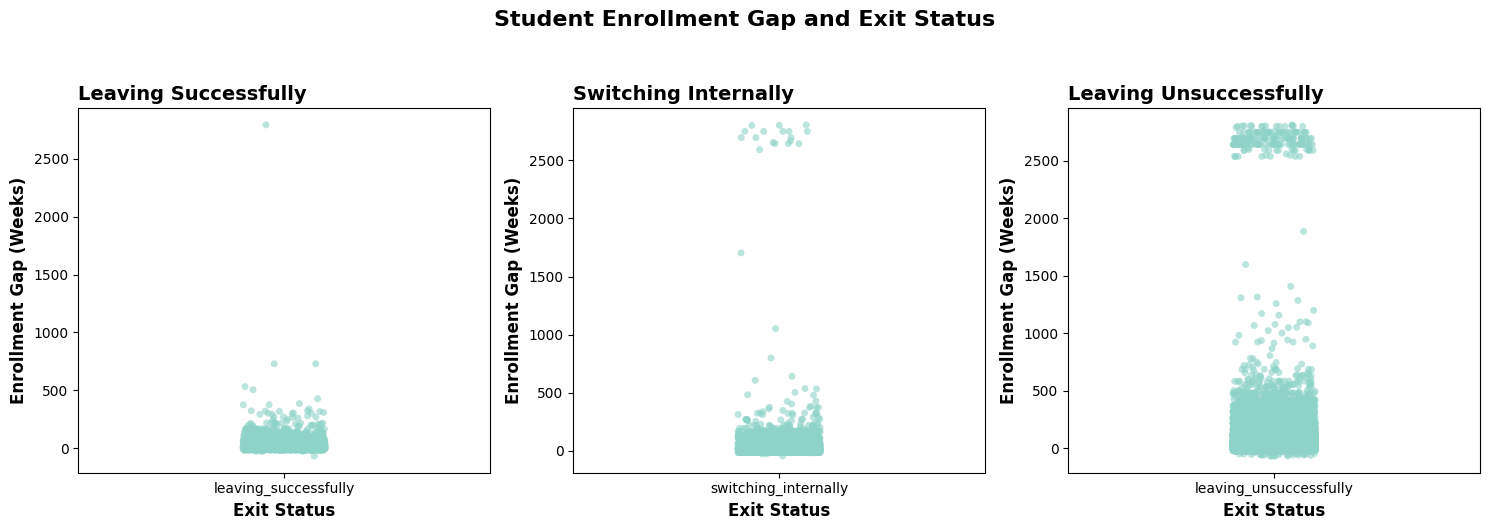

In [7]:
# Set figure size
plt.figure(figsize=(15, 5))

# Set the general title for the entire figure
plt.suptitle("Student Enrollment Gap and Exit Status", fontsize=16, fontweight='bold', y=1.05)

# Define the Exit_Status order to ensure "Leaving Unsuccessfully" is always on the right
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']

# Loop through each Exit_Status category in the specified order
for i, status in enumerate(exit_status_order):
    plt.subplot(1, 3, i + 1)
    
    # Plot the distribution of Student Enrollment Gap for each Exit_Status category using a strip plot
    sns.stripplot(x='Exit_Status', y='Student_Enrollment_Gap', data=data[data['Exit_Status'] == status], palette="Set3", jitter=True, alpha=0.6)
    
    # Title and labels for each subplot with left alignment
    plt.title(f"{status.replace('_', ' ').title()}", fontsize=14, fontweight='bold', loc='left')
    plt.xlabel("Exit Status", fontsize=12, fontweight='bold')
    plt.ylabel("Enrollment Gap (Weeks)", fontsize=12, fontweight='bold')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


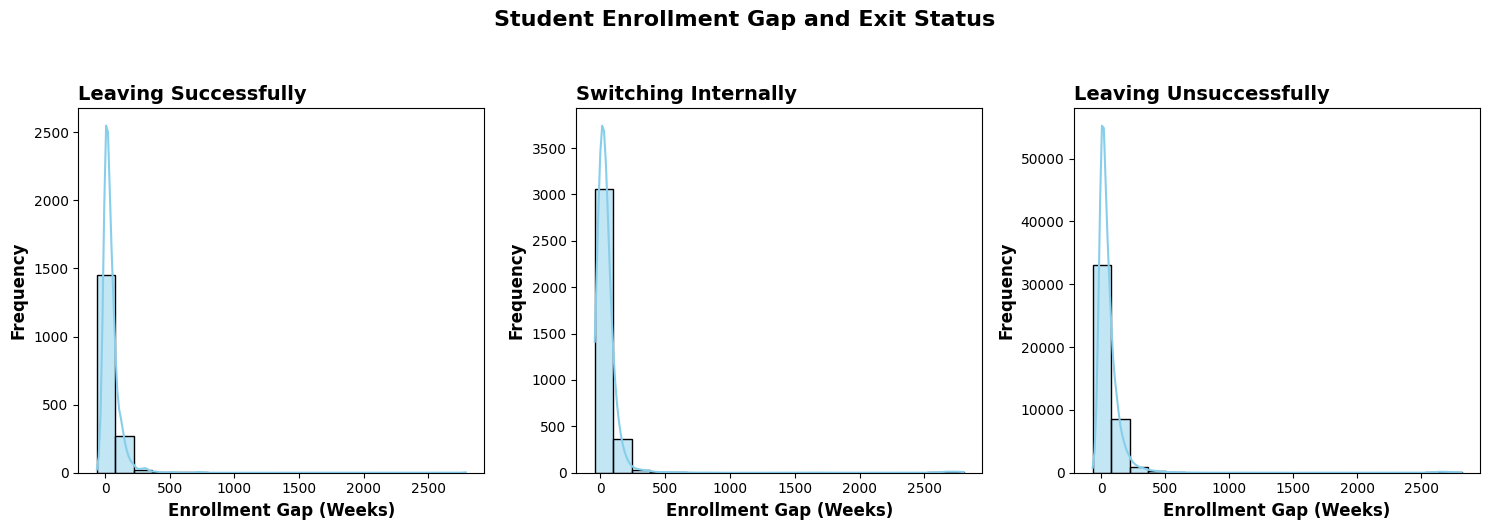

In [8]:
# Set figure size
plt.figure(figsize=(15, 5))

# Set the general title for the entire figure
plt.suptitle("Student Enrollment Gap and Exit Status", fontsize=16, fontweight='bold', y=1.05)

# Define the Exit_Status order to ensure "Leaving Unsuccessfully" is always on the right
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']

# Loop through each Exit_Status category in the specified order
for i, status in enumerate(exit_status_order):
    plt.subplot(1, 3, i + 1)
    
    # Plot the distribution of Student Enrollment Gap for each Exit_Status category using a histogram
    sns.histplot(data[data['Exit_Status'] == status]['Student_Enrollment_Gap'], kde=True, color='skyblue', bins=20)
    
    # Title and labels for each subplot with left alignment
    plt.title(f"{status.replace('_', ' ').title()}", fontsize=14, fontweight='bold', loc='left')
    plt.xlabel("Enrollment Gap (Weeks)", fontsize=12, fontweight='bold')
    plt.ylabel("Frequency", fontsize=12, fontweight='bold')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


# See if larger study programs have different dropout or switching rates.

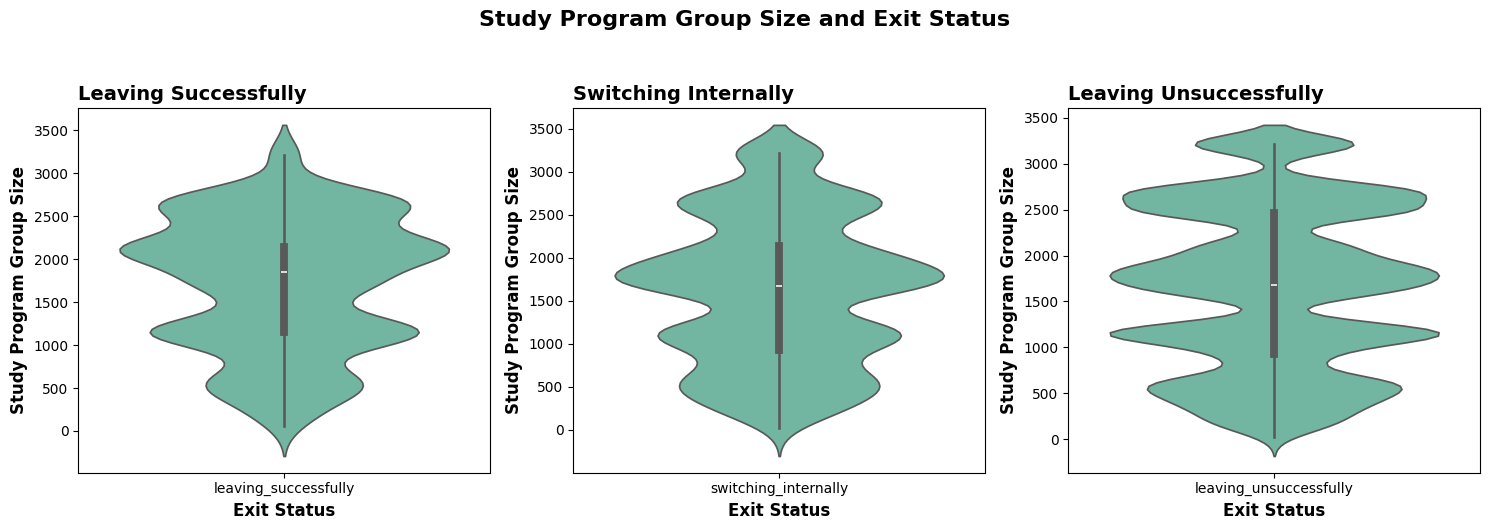

In [9]:
# Set figure size
plt.figure(figsize=(15, 5))

# Set the general title for the entire figure
plt.suptitle("Study Program Group Size and Exit Status", fontsize=16, fontweight='bold', y=1.05)

# Define the Exit_Status order to ensure consistent plotting
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']

# Loop through each Exit_Status category in the specified order
for i, status in enumerate(exit_status_order):
    plt.subplot(1, 3, i + 1)
    
    # Violin plot instead of boxplot
    sns.violinplot(x='Exit_Status', y='Study_Prog_Group_Size', data=data[data['Exit_Status'] == status], palette="Set2")
    
    # Title and labels for each subplot with left alignment
    plt.title(f"{status.replace('_', ' ').title()}", fontsize=14, fontweight='bold', loc='left')
    plt.xlabel("Exit Status", fontsize=12, fontweight='bold')
    plt.ylabel("Study Program Group Size", fontsize=12, fontweight='bold')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


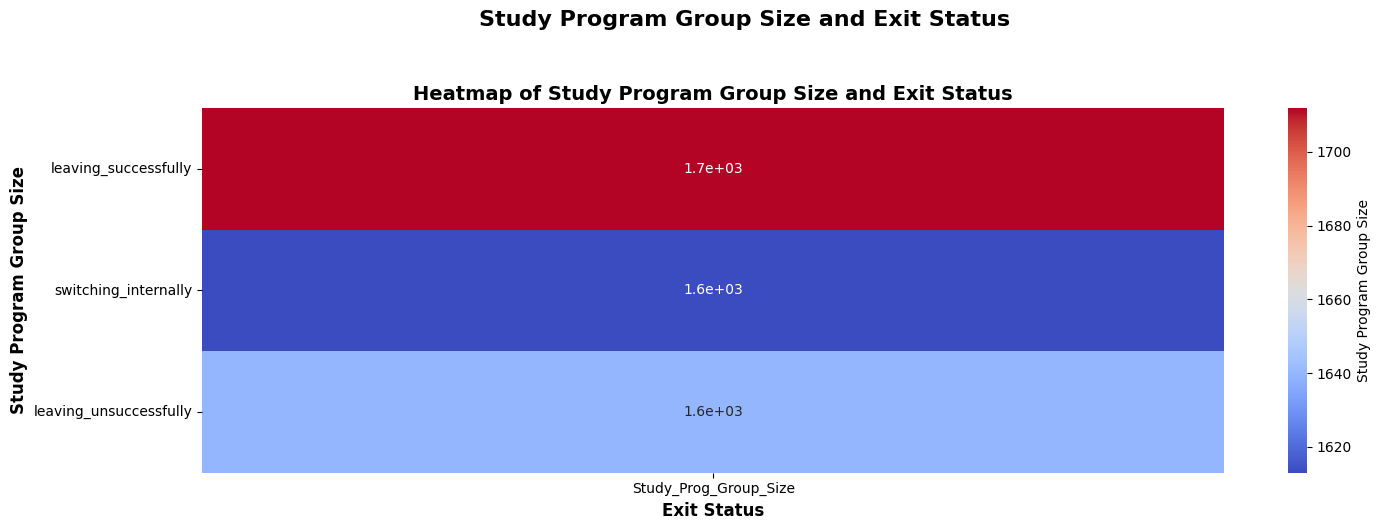

In [10]:
# Set figure size
plt.figure(figsize=(15, 5))

# Set the general title for the entire figure
plt.suptitle("Study Program Group Size and Exit Status", fontsize=16, fontweight='bold', y=1.05)

# Define the Exit_Status order to ensure consistent plotting
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']

# Prepare a pivot table with the desired order of Exit_Status
pivot_table = data.pivot_table(index='Exit_Status', values='Study_Prog_Group_Size', aggfunc='mean')

# Reorder the pivot table according to the defined Exit_Status order
pivot_table = pivot_table.loc[exit_status_order]

# Plot a heatmap (though it's more effective with multiple variables)
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", cbar_kws={'label': 'Study Program Group Size'})

# Title and labels
plt.title("Heatmap of Study Program Group Size and Exit Status", fontsize=14, fontweight='bold')
plt.xlabel("Exit Status", fontsize=12, fontweight='bold')
plt.ylabel("Study Program Group Size", fontsize=12, fontweight='bold')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


Insights:

Larger Study Program Groups and Success: The heatmap suggests that larger study programs (with an average group size of 1700) are associated with students who leave successfully.

Similar Group Sizes in Unsuccessful and Switching Internally: The group size is the same (1600) for students who either leave unsuccessfully or switch internally, which might indicate that the size of the study group isn't strongly affecting whether students switch or leave unsuccessfully.

# Analyze if students from certain prior education backgrounds have higher dropout rates.

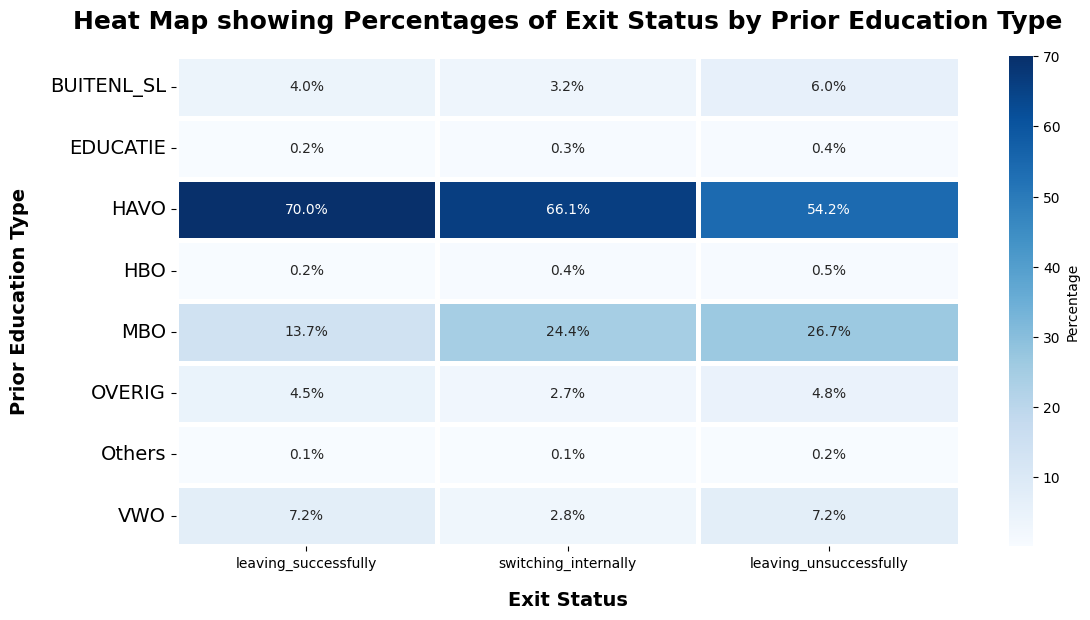

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure Exit_Status is properly ordered
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
data['Exit_Status'] = pd.Categorical(data['Exit_Status'], categories=exit_status_order, ordered=True)

# Create a contingency table (cross-tabulation) of counts
heatmap_data = pd.crosstab(data['Prior_Edu_Type'], data['Exit_Status'])

# Convert counts to percentages (column-wise)
heatmap_data_percentage = heatmap_data.div(heatmap_data.sum(axis=0), axis=1) * 100

# Format values to include the % symbol
annot_labels = heatmap_data_percentage.applymap(lambda x: f"{x:.1f}%")

# If the heatmap_data is not empty, plot the heatmap
if not heatmap_data_percentage.empty:
    # Set figure size
    plt.figure(figsize=(14, 7))  # Keep large size for clarity

    # Plot the heatmap with percentage labels
    ax = sns.heatmap(
        heatmap_data_percentage, 
        annot=annot_labels, 
        cmap='Blues', 
        fmt="", 
        linewidths=2.5,  # Increased line width to create more spacing
        cbar_kws={'label': 'Percentage'}
    )

    # Adjust tick labels to increase vertical spacing
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, rotation=0, verticalalignment='center')

    # Title and labels
    plt.title("Heat Map showing Percentages of Exit Status by Prior Education Type", fontsize=18, fontweight='bold', pad=20)
    plt.xlabel("Exit Status", fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel("Prior Education Type", fontsize=14, fontweight='bold', labelpad=15)

    # Adjust layout to add vertical spacing
    plt.subplots_adjust(left=0.25, right=0.95, top=0.9, bottom=0.2)  

    # Show the plot
    plt.show()
else:
    print("Heatmap data is empty. Please check for missing values or unexpected data.")


# Prior_Edu_Country – see if students from specific countries have different exit statuses.

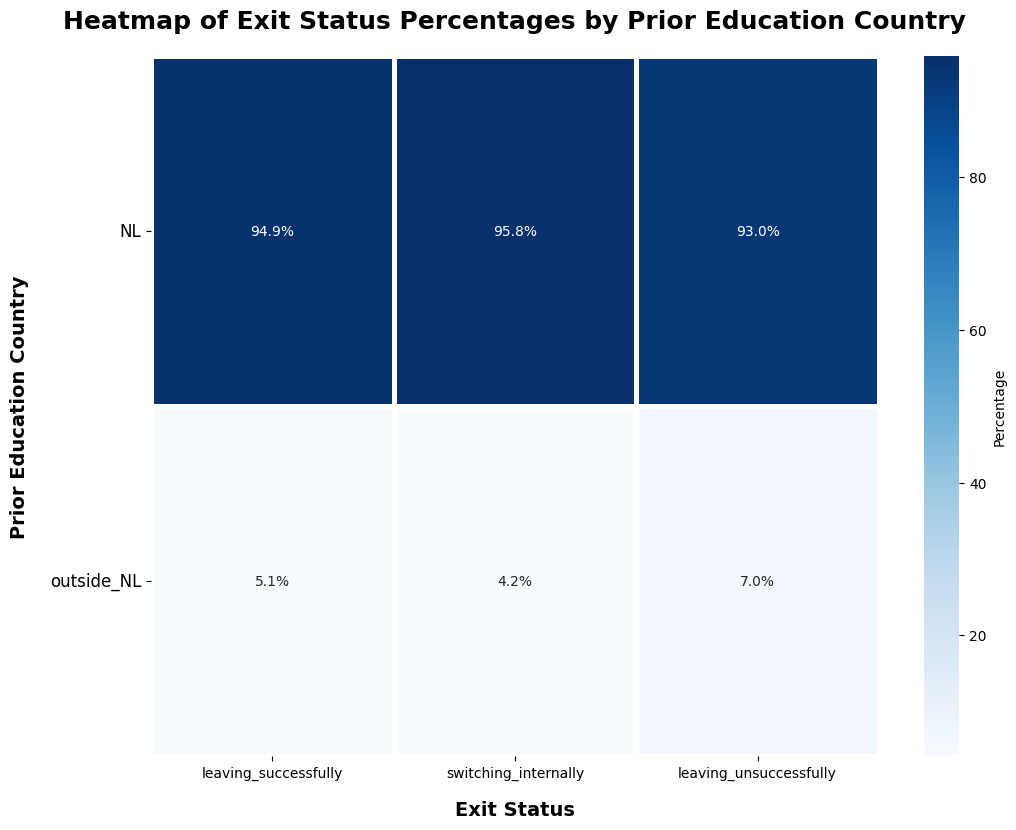

In [12]:
# Ensure Exit_Status is properly ordered
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
data['Exit_Status'] = pd.Categorical(data['Exit_Status'], categories=exit_status_order, ordered=True)

# Create a contingency table (cross-tabulation) of counts
heatmap_data = pd.crosstab(data['Prior_Edu_Country'], data['Exit_Status'])

# Convert counts to percentages (column-wise)
heatmap_data_percentage = heatmap_data.div(heatmap_data.sum(axis=0), axis=1) * 100

# Calculate the average percentage per Prior Education Country across all Exit_Statuses
heatmap_data_percentage["Avg_Percentage"] = heatmap_data_percentage.mean(axis=1)

# Sort by the highest average percentage if the ranking holds across all Exit_Statuses
if heatmap_data_percentage.rank(axis=0, method='min').var(axis=1).max() == 0:
    heatmap_data_percentage = heatmap_data_percentage.sort_values("Avg_Percentage", ascending=False)

# Drop the temporary Avg_Percentage column after sorting
heatmap_data_percentage = heatmap_data_percentage.drop(columns=["Avg_Percentage"])

# Format values to include the % symbol
annot_labels = heatmap_data_percentage.applymap(lambda x: f"{x:.1f}%")

# If the heatmap_data is not empty, plot the heatmap
if not heatmap_data_percentage.empty:
    # Set figure size
    plt.figure(figsize=(14, 10))  # Increased height for better spacing

    # Plot the heatmap with percentage labels
    ax = sns.heatmap(
        heatmap_data_percentage, 
        annot=annot_labels, 
        cmap='Blues', 
        fmt="", 
        linewidths=2.5,  # Increased line width for spacing
        cbar_kws={'label': 'Percentage'}
    )

    # Adjust tick labels for better readability
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, rotation=0, verticalalignment='center')

    # Title and labels
    plt.title("Heatmap of Exit Status Percentages by Prior Education Country", fontsize=18, fontweight='bold', pad=20)
    plt.xlabel("Exit Status", fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel("Prior Education Country", fontsize=14, fontweight='bold', labelpad=15)

    # Adjust layout to add vertical spacing
    plt.subplots_adjust(left=0.3, right=0.95, top=0.9, bottom=0.2)  

    # Show the plot
    plt.show()
else:
    print("Heatmap data is empty. Please check for missing values or unexpected data.")


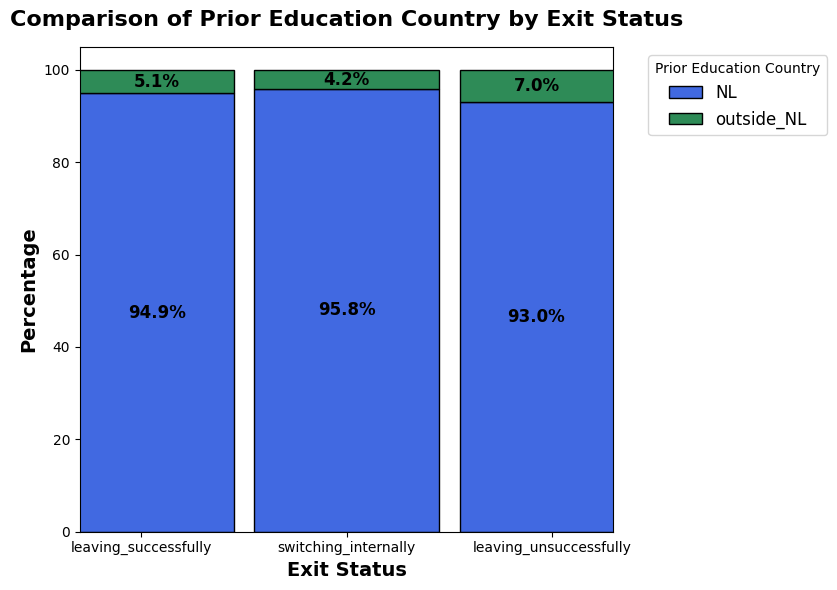

In [13]:
# Ensure Exit_Status is properly ordered
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
data['Exit_Status'] = pd.Categorical(data['Exit_Status'], categories=exit_status_order, ordered=True)

# Compute percentages within each Exit_Status
country_exit_counts = pd.crosstab(data['Exit_Status'], data['Prior_Edu_Country'], normalize=0) * 100

# Define custom colors (NL = Blue, outside_NL = Green)
custom_colors = {'NL': 'royalblue', 'outside_NL': 'seagreen'}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the stacked bar chart with custom colors
country_exit_counts.plot(
    kind='bar', 
    stacked=True, 
    color=[custom_colors[col] for col in country_exit_counts.columns],  # Assign colors manually
    edgecolor='black', 
    width=0.9,  
    ax=ax
)

# Reduce space between bars by adjusting x-axis limits
ax.set_xlim(-0.3, len(exit_status_order) - 0.7)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=12, color='black', weight='bold')

# Titles and labels
plt.title("Comparison of Prior Education Country by Exit Status", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Exit Status", fontsize=14, fontweight='bold')
plt.ylabel("Percentage", fontsize=14, fontweight='bold')
plt.xticks(rotation=0)

# Move legend outside the plot (top right, outside)
plt.legend(
    title="Prior Education Country", 
    fontsize=12, 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1)
)

# Adjust layout to fit the legend properly
plt.tight_layout(rect=[0, 0, 0.85, 1])  

# Show plot
plt.show()


# Study_Prog_Exam_Completed – Check if completing the program exam is linked to success or dropout.

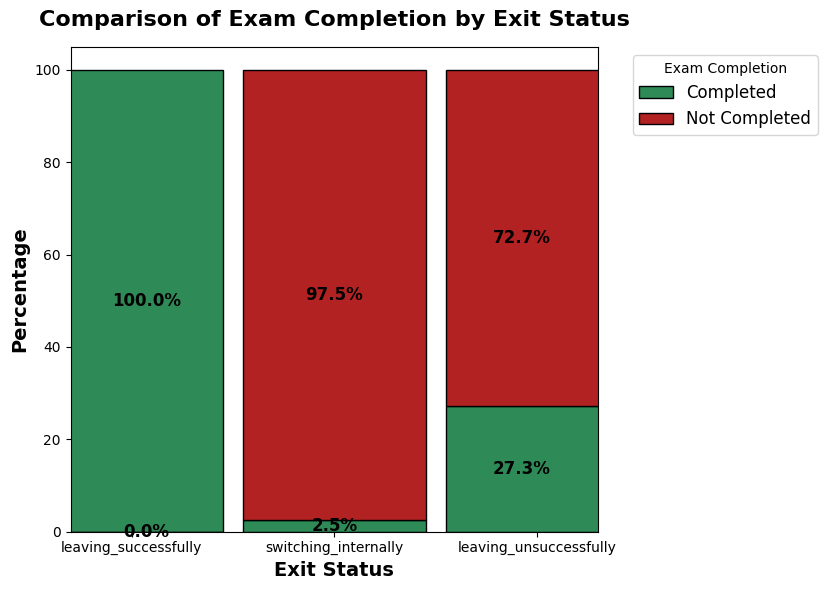

In [14]:
# Ensure Exit_Status is properly ordered
exit_status_order = ['leaving_successfully', 'switching_internally', 'leaving_unsuccessfully']
data['Exit_Status'] = pd.Categorical(data['Exit_Status'], categories=exit_status_order, ordered=True)

# Rename values for better readability (0 = Not Completed, 1 = Completed)
data['Study_Prog_Exam_Completed'] = data['Study_Prog_Exam_Completed'].map({0: 'Not Completed', 1: 'Completed'})

# Compute percentages within each Exit_Status
exam_exit_counts = pd.crosstab(data['Exit_Status'], data['Study_Prog_Exam_Completed'], normalize=0) * 100

# Define custom colors (Completed = Green, Not Completed = Red)
custom_colors = {'Completed': 'seagreen', 'Not Completed': 'firebrick'}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the stacked bar chart with custom colors
exam_exit_counts.plot(
    kind='bar', 
    stacked=True, 
    color=[custom_colors[col] for col in exam_exit_counts.columns],  # Assign colors manually
    edgecolor='black', 
    width=0.9,  
    ax=ax
)

# Reduce space between bars by adjusting x-axis limits
ax.set_xlim(-0.3, len(exit_status_order) - 0.7)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=12, color='black', weight='bold')

# Titles and labels
plt.title("Comparison of Exam Completion by Exit Status", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Exit Status", fontsize=14, fontweight='bold')
plt.ylabel("Percentage", fontsize=14, fontweight='bold')
plt.xticks(rotation=0)

# Move legend outside the plot (top right, outside)
plt.legend(
    title="Exam Completion", 
    fontsize=12, 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1)
)

# Adjust layout to fit the legend properly
plt.tight_layout(rect=[0, 0, 0.85, 1])  

# Show plot
plt.show()


In [15]:
data.columns

Index(['Enrollment_ID', 'Study_Prog_Name', 'Study_Prog_Exam_Completed',
       'Prior_Edu_Type', 'Prior_Edu_School_Location', 'Prior_Edu_Postcode',
       'Prior_Edu_Country', 'Study_Prog_Group_Size', 'Student_Enrollment_Gap',
       'Exit_Status'],
      dtype='object')

# Test for correlation matrix using Cramér's V Correlation Matrix for categorical values

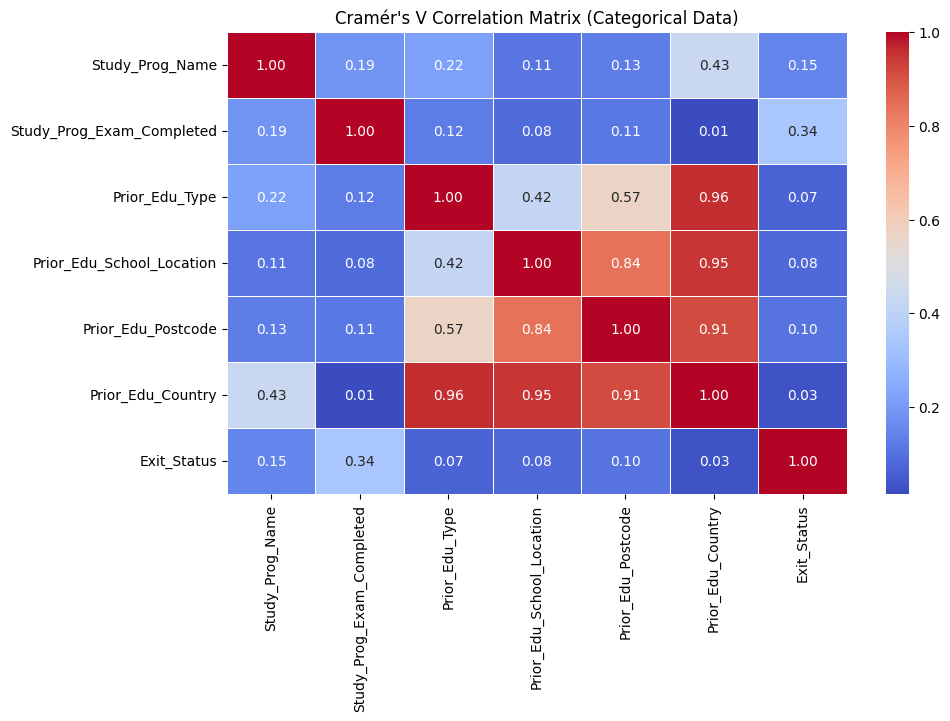

In [ ]:
# Identify categorical columns dynamically
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

# Define function to calculate Cramér's V
def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical correlation."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0

# Compute Cramér’s V matrix for categorical variables
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0  # Perfect correlation with itself
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

# Convert values to float
cramers_v_matrix = cramers_v_matrix.astype(float)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cramers_v_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Cramér's V Correlation Matrix (Categorical Data)")
plt.show()
